# SCAM IOP composite scatter

Scatter plot of time-mean values across IOP cases, run types, and vertical resolutions.

- **X-axis** — IOP groups (TOGA-COARE, GATE III, ARM 1995, ARM 1997)
- **Colour** — run type (CAM6 | CAM7 | CAM7 ZM-off)
- **Marker** — vertical resolution (L32 | L48 | L58 | L256)

In [1]:
import os
import glob
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import xarray as xr

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

In [2]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

print('Imports OK')

Imports OK


In [3]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)
    local_directory="/glade/derecho/scratch/rneale/dask-temp"  # <--- custom temp dir
)

cluster.scale(jobs=4)
client = Client(cluster)

client


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.176:43221,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Compute/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
# ── configuration ────────────────────────────────────────────────────────────

BASE_DIR = "/glade/work/rneale/scam_cases/cases/ZM_PBL_paper"
IOP_DIR  = "/glade/work/rneale/scam_cases/iops"

IOPS       = ["togaII",     "gateIII",  "arm95",    "arm97"]
IOP_LABELS = ["TOGA-COARE", "GATE III", "ARM 1995", "ARM 1997"]

# IOP observation files (capitalised filenames on disk)
IOP_OBS_FILES = {
    "togaII":  "TOGAII_4scam.nc",
    "gateIII": "GATEIII_4scam.nc",
    "arm95":   "ARM95_4scam.nc",
    "arm97":   "ARM97_4scam.nc",
}

# Map from model variable name → observed variable name in the IOP file.
OBS_VAR_MAP = {
    "PRECT": "Prec",
    "LHFLX": "lhflx",
    "SHFLX": "shflx",
    "T":     "T",
    "Q":     "q",
    "U":     "u",
    "V":     "v",
    "OMEGA": "omega",
    "RELHUM": "relhum",
}

RUN_TYPES  = ["cam6-phys.000", "cam7-phys.000", "cam7-phys.001"]
RUN_LABELS = ["CAM6",          "CAM7",          "CAM7 as CAM6"]
RUN_COLORS = ["#1f77b4",       "#ff7f0e",        "#2ca02c"]

LEVELS        = ["L32", "L48", "L58", "L256"]
LEVEL_MARKERS = {"L32": "o", "L48": "s", "L58": "^", "L256": "D"}
MARKER_SIZE   = 90
MARKER_EDGE   = 0.6

IOP_STEP        = 3.5
RUNTYPE_OFFSETS = [-0.55, 0.0, 0.55]

# Explicit per-variable overrides — highest priority.
UNIT_CONVERSIONS = {
    "PRECT": (86_400 * 1000, "mm day⁻¹"),
    "PRECC": (86_400 * 1000, "mm day⁻¹"),
    "PRECL": (86_400 * 1000, "mm day⁻¹"),
    # CLUBB static energy tendency [J/(kg s)] → K/day: divide by Cp (1004 J/kg/K) × 86400 s/day
    "STEND_CLUBB": (86_400 / 1004.0, "K day⁻¹"),
}

# Auto-conversions keyed on the units attribute string read from the netCDF file.
# Used for any variable not listed in UNIT_CONVERSIONS above.
AUTO_UNIT_CONVERSIONS = {
    "K/s":      (86_400,             "K day⁻¹"),
    "kg/kg":    (1_000,              "g kg⁻¹"),
    "kg/kg/s":  (1_000 * 86_400,     "g kg⁻¹ day⁻¹"),
    "kg/kg /s": (1_000 * 86_400,     "g kg⁻¹ day⁻¹"),  # space variant in some files
}

In [5]:
# ── helpers ──────────────────────────────────────────────────────────────────

def find_h0i_file(iop, run_type, level):
    case_dir = os.path.join(BASE_DIR, f"FSCAM.T42_T42.{iop}.{run_type}.{level}", "run")
    matches = glob.glob(os.path.join(case_dir, "*.cam.h0i.*.nc"))
    return matches[0] if matches else None


def find_pressure_level_idx(fpath, plev):
    """Return the 0-based model level index nearest to plev (hPa)."""
    ds = xr.open_dataset(fpath, decode_times=False)
    ps_mean  = float(ds["PS"].mean().values) if "PS" in ds else 101325.0
    p0       = float(ds["P0"].values)        if "P0" in ds else 100000.0
    pres_hpa = (ds["hyam"].values * p0 + ds["hybm"].values * ps_mean) / 100.0
    ds.close()
    return int(np.argmin(np.abs(pres_hpa - plev)))


def get_display_scale(varname):
    """Return (scale, display_units) for varname.

    Priority:
      1. UNIT_CONVERSIONS  — explicit per-variable overrides (e.g. PRECT)
      2. AUTO_UNIT_CONVERSIONS — matched against the units attribute in the
         first available h0i file (e.g. K/s → K day⁻¹, kg/kg → g kg⁻¹)
      3. (1.0, raw_units) fallback
    """
    if varname in UNIT_CONVERSIONS:
        return UNIT_CONVERSIONS[varname]

    for iop in IOPS:
        for rt in RUN_TYPES:
            for lv in LEVELS:
                fpath = find_h0i_file(iop, rt, lv)
                if fpath is None:
                    continue
                ds = xr.open_dataset(fpath, decode_times=False)
                if varname in ds:
                    raw_units = ds[varname].attrs.get("units", "")
                    ds.close()
                    return AUTO_UNIT_CONVERSIONS.get(raw_units,
                                                     (1.0, raw_units or "model units"))
                ds.close()

    return (1.0, "model units")


def compute_stats(fpath, varname, plev=None, lev_idx=None):
    """Return dict of {mean, std, min, max} for varname (all NaN if variable missing).

    lev_idx : 0-based level index (takes priority over plev if both given)
    plev    : target pressure in hPa; nearest hybrid level is selected
    """
    nan_result = dict(mean=np.nan, std=np.nan, min=np.nan, max=np.nan)
    ds = xr.open_dataset(fpath, decode_times=False)
    if varname not in ds:
        ds.close()
        return nan_result
    da = ds[varname].squeeze()
    if "lev" in da.dims:
        if lev_idx is not None:
            da = da.isel(lev=lev_idx)
        elif plev is not None:
            ps_mean  = float(ds["PS"].mean().values) if "PS" in ds else 101325.0
            p0       = float(ds["P0"].values)        if "P0" in ds else 100000.0
            pres_hpa = (ds["hyam"].values * p0 + ds["hybm"].values * ps_mean) / 100.0
            idx      = int(np.argmin(np.abs(pres_hpa - plev)))
            da       = da.isel(lev=idx)
        else:
            da = da.mean(dim="lev")
    ds.close()
    return dict(
        mean=float(da.mean().values),
        std =float(da.std().values),
        min =float(da.min().values),
        max =float(da.max().values),
    )


def compute_mean(fpath, varname, plev=None, lev_idx=None):
    return compute_stats(fpath, varname, plev=plev, lev_idx=lev_idx)["mean"]


def get_obs_mean(iop, varname, plev=None, lev_idx=None):
    """Return time-mean observed value in display units, or np.nan if unavailable."""
    obs_varname = OBS_VAR_MAP.get(varname)
    fpath = os.path.join(IOP_DIR, IOP_OBS_FILES.get(iop, ""))
    if obs_varname is None or not os.path.exists(fpath):
        return np.nan

    ds = xr.open_dataset(fpath, decode_times=False)
    if obs_varname not in ds:
        ds.close()
        return np.nan

    da = ds[obs_varname].squeeze()
    obs_units = ds[obs_varname].attrs.get("units", "").lower().strip()

    if "lev" in da.dims:
        if lev_idx is not None:
            da = da.isel(lev=lev_idx)
        elif plev is not None:
            pres_hpa = ds["lev"].values / 100.0   # IOP lev is in Pa
            idx = int(np.argmin(np.abs(pres_hpa - plev)))
            da = da.isel(lev=idx)
        else:
            da = da.mean(dim="lev")

    raw_val = float(da.mean().values)
    ds.close()

    scale, _ = get_display_scale(varname)

    # Precipitation: some IOP files use mm/s instead of m/s
    if varname in ("PRECT", "PRECC", "PRECL") and "mm" in obs_units:
        return raw_val * 86_400          # mm/s → mm/day

    return raw_val * scale

In [6]:
# ── plot function ─────────────────────────────────────────────────────────────

STAT_LABELS = {
    "mean": "time-mean",
    "min":  "minimum",
    "max":  "maximum",
    "std":  "std dev",
}


def _auto_outfile(varname, plev, lev_idx, stat):
    """Build an output filename from the plot parameters."""
    parts = [varname]
    if lev_idx is not None:
        parts.append("levSFC" if lev_idx == -1 else f"lev{lev_idx}")
    elif plev is not None:
        parts.append(f"{int(plev)}hPa")
    parts.append(stat)
    return "_".join(parts) + ".png"


def make_plot(varname, plev=None, lev_idx=None, outfile=None, obs=False,
              stat="mean"):
    """
    varname : CAM variable name (e.g. "PRECT", "LHFLX", "T", "ZMDT", "Q")
    plev    : pressure level in hPa — selects nearest model level; prints level index
    lev_idx : 0-based model level index (overrides plev); -1 = surface level
    outfile : output path (None = auto-generate as <VAR>[_lev|_hPa]_<stat>.png)
    obs     : if True, overplot observed IOP mean as a black star where available
    stat    : which statistic to plot — "mean" | "min" | "max" | "std"
    """
    if stat not in STAT_LABELS:
        raise ValueError(f"stat must be one of {list(STAT_LABELS)}; got {stat!r}")
    scale, units = get_display_scale(varname)
    outfile = outfile or _auto_outfile(varname, plev, lev_idx, stat)

    # ── determine display string for level selection ───────────────────────────
    if lev_idx == -1:
        lev_str = " @ surface level"
    elif lev_idx is not None:
        lev_str = f" @ lev {lev_idx}"
    elif plev is not None:
        ref_idx = None
        for iop in IOPS:
            for rt in RUN_TYPES:
                for lv in LEVELS:
                    fpath = find_h0i_file(iop, rt, lv)
                    if fpath:
                        ref_idx = find_pressure_level_idx(fpath, plev)
                        print(f"  {lv}: nearest level to {plev} hPa → lev {ref_idx}")
                break
        idx_str = f" (lev {ref_idx})" if ref_idx is not None else ""
        lev_str = f" @ {plev} hPa{idx_str}"
    else:
        lev_str = ""

    fig, ax = plt.subplots(figsize=(12, 5))

    # ── model scatter ──────────────────────────────────────────────────────────
    for i_iop, iop in enumerate(IOPS):
        x_iop = i_iop * IOP_STEP
        for rt, rt_color, rt_offset in zip(RUN_TYPES, RUN_COLORS, RUNTYPE_OFFSETS):
            x_pos = x_iop + rt_offset
            for level in LEVELS:
                fpath = find_h0i_file(iop, rt, level)
                if fpath is None:
                    continue
                st = compute_stats(fpath, varname, plev=plev, lev_idx=lev_idx)
                val = st[stat] * scale
                if np.isnan(val):
                    continue
                ax.scatter(x_pos, val, s=MARKER_SIZE, c=rt_color,
                           marker=LEVEL_MARKERS[level],
                           linewidths=MARKER_EDGE, edgecolors="k", zorder=4)

    # ── observed means (black stars) ──────────────────────────────────────────
    iop_centers = [i * IOP_STEP for i in range(len(IOPS))]
    obs_plotted = False
    if obs:
        for iop, xc in zip(IOPS, iop_centers):
            obs_val = get_obs_mean(iop, varname, plev=plev, lev_idx=lev_idx)
            if not np.isnan(obs_val):
                ax.scatter(xc, obs_val, s=220, c="k", marker="*",
                           linewidths=0.5, edgecolors="k", zorder=5)
                obs_plotted = True

    # ── x-axis ────────────────────────────────────────────────────────────────
    ax.set_xticks(iop_centers)
    ax.set_xticklabels(IOP_LABELS, fontsize=11)
    for ic in iop_centers[1:]:
        ax.axvline(ic - IOP_STEP / 2, color="0.8", lw=0.8, zorder=1)
    ax.set_xlim(iop_centers[0] - IOP_STEP * 0.6, iop_centers[-1] + IOP_STEP * 0.6)

    # ── y-axis ────────────────────────────────────────────────────────────────
    ax.set_ylabel(f"{varname}{lev_str}  [{units}]", fontsize=11)
    ax.set_title(f"SCAM IOP ensemble — {STAT_LABELS[stat]} {varname}{lev_str}", fontsize=12)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # ── legends (figure-level to avoid axes-bbox clipping) ───────────────────
    color_handles = [
        mlines.Line2D([], [], color=c, marker="o", markersize=8,
                      markeredgecolor="k", markeredgewidth=0.6,
                      linestyle="none", label=lbl)
        for c, lbl in zip(RUN_COLORS, RUN_LABELS)
    ]
    if obs and obs_plotted:
        color_handles.append(
            mlines.Line2D([], [], color="k", marker="*", markersize=11,
                          linestyle="none", label="Observed")
        )

    marker_handles = [
        mlines.Line2D([], [], color="0.4", marker=LEVEL_MARKERS[lv], markersize=8,
                      markeredgecolor="k", markeredgewidth=0.6,
                      linestyle="none", label=lv)
        for lv in LEVELS
    ]

    fig.tight_layout(rect=[0, 0, 0.74, 1])
    fig.canvas.draw()
    rx = ax.get_position().x1 + 0.01

    fig.legend(handles=color_handles, title="Run type",
               bbox_to_anchor=(rx, 0.98), loc="upper left",
               fontsize=9, title_fontsize=9, framealpha=0.9, borderaxespad=0)
    fig.legend(handles=marker_handles, title="Vert. resolution",
               bbox_to_anchor=(rx, 0.38), loc="upper left",
               fontsize=9, title_fontsize=9, framealpha=0.9, borderaxespad=0)

    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    print(f"Saved → {outfile}")
    plt.show()

In [7]:
# ── sort-contour plot function ─────────────────────────────────────────────────

def _load_time_height(fpath, varname):
    """Return (array, pres_hpa) where array has shape (time, lev)."""
    ds = xr.open_dataset(fpath, decode_times=False)
    if varname not in ds:
        ds.close()
        return None, None
    da = ds[varname].squeeze()
    for dim in list(da.dims):
        if dim not in ("time", "lev"):
            da = da.isel({dim: 0})
    ps_mean  = float(ds["PS"].mean().values) if "PS" in ds else 101325.0
    p0       = float(ds["P0"].values)        if "P0" in ds else 100000.0
    pres_hpa = (ds["hyam"].values * p0 + ds["hybm"].values * ps_mean) / 100.0
    ds.close()
    return da.values, pres_hpa


def _load_time_series(fpath, varname):
    """Return 1-D numpy array (time,) for a scalar-per-timestep variable."""
    ds = xr.open_dataset(fpath, decode_times=False)
    if varname not in ds:
        ds.close()
        return None
    da = ds[varname].squeeze()
    for dim in list(da.dims):
        if dim != "time":
            da = da.mean(dim=dim)
    ds.close()
    return da.values


def make_sort_contour_plot(
    zvar, xvar,
    iop=None, run_type=None, level=None,
    outfile=None,
    plev_min=None, plev_max=None,
    nlevs=20,
    nbins=None,
    cmap="RdBu_r",
    symmetric=True,
):
    """
    Contour plot of a time×height field (zvar) with time samples sorted by
    increasing values of a 1-D time field (xvar).

    Parameters
    ----------
    zvar      : CAM variable with (time, lev) dims — e.g. "ZMDT"
    xvar      : CAM 1-D time variable for sorting the x-axis — e.g. "PRECT"
    iop       : IOP key (default: IOPS[0])
    run_type  : run-type key (default: RUN_TYPES[0])
    level     : vertical-resolution key, e.g. "L32" (default: LEVELS[0])
    outfile   : output path (None → auto-generate)
    plev_min  : upper bound of displayed pressure axis in hPa (column top)
    plev_max  : lower bound of displayed pressure axis in hPa (near surface)
    nlevs     : number of filled-contour levels
    nbins     : if set, group the sorted time steps into this many equal-sized
                bins and plot bin means (smoother); None plots every sample
    cmap      : matplotlib colormap name
    symmetric : if True, colour limits are ±98th-percentile of |data|
                (good for signed tendencies); False uses per-percentile limits
    """
    iop      = iop      or IOPS[0]
    run_type = run_type or RUN_TYPES[0]
    level    = level    or LEVELS[0]

    fpath = find_h0i_file(iop, run_type, level)
    if fpath is None:
        raise FileNotFoundError(
            f"No h0i file found for iop={iop!r}  run_type={run_type!r}  level={level!r}"
        )

    # ── load and scale z (time × lev) ────────────────────────────────────────
    z_raw, pres_hpa = _load_time_height(fpath, zvar)
    if z_raw is None:
        raise KeyError(f"Variable {zvar!r} not found in {fpath}")
    z_scale, z_units = get_display_scale(zvar)
    z = z_raw * z_scale                          # (time, lev)

    # ── load and scale x (time,) ──────────────────────────────────────────────
    x_raw = _load_time_series(fpath, xvar)
    if x_raw is None:
        raise KeyError(f"Variable {xvar!r} not found in {fpath}")
    x_scale, x_units = get_display_scale(xvar)
    x = x_raw * x_scale                          # (time,)

    # ── sort time steps by x increasing ──────────────────────────────────────
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    z_sorted = z[sort_idx, :]                    # (time_sorted, lev)

    # ── optional binning ─────────────────────────────────────────────────────
    if nbins is not None:
        n = len(x_sorted)
        idx_edges = np.linspace(0, n, nbins + 1, dtype=int)
        x_sorted = np.array([x_sorted[idx_edges[b]:idx_edges[b+1]].mean()
                              for b in range(nbins)])
        z_sorted = np.array([z_sorted[idx_edges[b]:idx_edges[b+1], :].mean(axis=0)
                              for b in range(nbins)])

    # ── restrict to requested pressure range ──────────────────────────────────
    pmask = np.ones(len(pres_hpa), dtype=bool)
    if plev_min is not None:
        pmask &= pres_hpa >= plev_min
    if plev_max is not None:
        pmask &= pres_hpa <= plev_max
    pres_plot = pres_hpa[pmask]
    z_plot    = z_sorted[:, pmask]               # (samples, lev_subset)

    # ── colour limits ──────────────────────────────────────────────────────────
    if symmetric:
        vmax = np.nanpercentile(np.abs(z_plot), 98)
        vmin = -vmax
    else:
        vmin = np.nanpercentile(z_plot,  2)
        vmax = np.nanpercentile(z_plot, 98)

    levels_cf = np.linspace(vmin, vmax, nlevs + 1)

    # ── plot ───────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))

    cf = ax.contourf(
        x_sorted, pres_plot, z_plot.T,
        levels=levels_cf, cmap=cmap, extend="both",
    )
    ax.contour(
        x_sorted, pres_plot, z_plot.T,
        levels=levels_cf, colors="k", linewidths=0.25, alpha=0.35,
    )

    cb = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.9)
    cb.set_label(f"{zvar}  [{z_units}]", fontsize=10)

    ax.set_xlabel(f"{xvar}  [{x_units}]", fontsize=11)
    ax.set_ylabel("Pressure  [hPa]", fontsize=11)
    ax.invert_yaxis()

    iop_label = IOP_LABELS[IOPS.index(iop)]
    rt_label  = RUN_LABELS[RUN_TYPES.index(run_type)]
    bin_str   = f"  ({nbins} bins)" if nbins is not None else ""
    ax.set_title(
        f"{zvar} sorted by {xvar}{bin_str} — {iop_label} / {rt_label} / {level}",
        fontsize=12,
    )

    # ── save ───────────────────────────────────────────────────────────────────
    if outfile is None:
        bin_tag = f"_{nbins}bins" if nbins is not None else ""
        outfile = f"scam_sortcontour_{zvar}_by_{xvar}{bin_tag}_{iop}_{run_type}_{level}.png"

    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    print(f"Saved → {outfile}")
    plt.show()


Saved → scam_sortcontour_ZMDT_by_PRECT_20bins_togaII_cam7-phys.000_L58.png


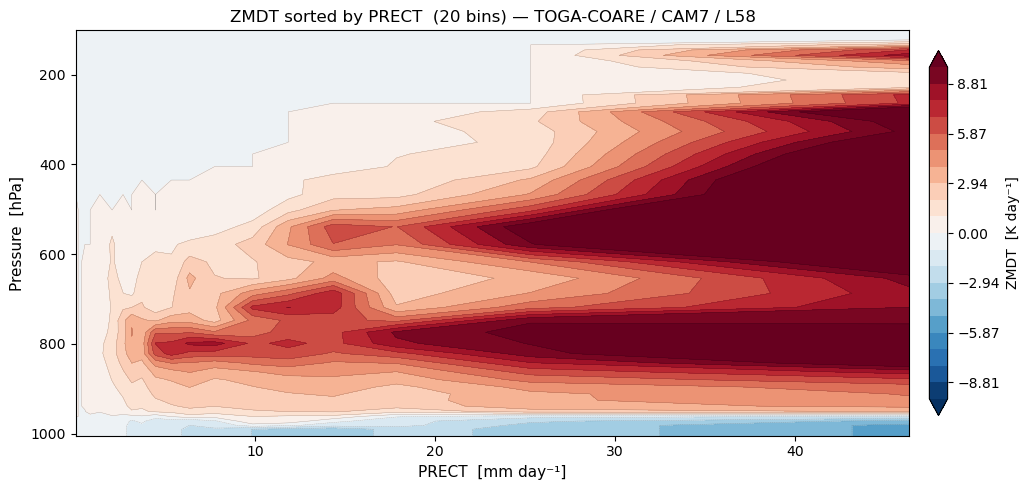

In [8]:
# ── sort-contour run ──────────────────────────────────────────────────────────
# Plots a time×height field (zvar) with time steps sorted by increasing xvar.
#
# zvar      : (time, lev) CAM variable  — e.g. "ZMDT", "T", "Q", "OMEGA"
# xvar      : 1-D time variable for sorting — e.g. "PRECT", "CAPE", "LHFLX"
# iop       : "togaII" | "gateIII" | "arm95" | "arm97"
# run_type  : "cam6-phys.000" | "cam7-phys.000" | "cam7-phys.001"
# level     : "L32" | "L48" | "L58" | "L256"
# plev_min  : top of displayed pressure range in hPa (None = column top)
# plev_max  : bottom of displayed pressure range in hPa (None = surface)
# nbins     : group sorted samples into this many equal-count bins and plot
#             bin means (smoother result); None = plot every individual sample
# symmetric : True  → ±98th-pct colour limits  (best for signed tendencies)
#             False → 2nd/98th-pct limits       (best for one-sided fields)

zvar      = "ZMDT"
xvar      = "PRECT"
iop       = "togaII"
run_type  = "cam7-phys.000"
level     = "L58"
plev_min  = 100.    # hPa — top of displayed pressure range (None = all)
plev_max  = 1100.   # hPa — bottom (None = all)
nbins     = 20      # number of bins (None = all individual samples)
symmetric = True
cmap      = "RdBu_r"
nlevs     = 20
outfile   = None    # None = auto-generate filename

make_sort_contour_plot(
    zvar, xvar,
    iop=iop, run_type=run_type, level=level,
    outfile=outfile,
    plev_min=plev_min, plev_max=plev_max,
    nbins=nbins,
    nlevs=nlevs, cmap=cmap, symmetric=symmetric,
)


Saved → PLEL_levSFC_mean.png


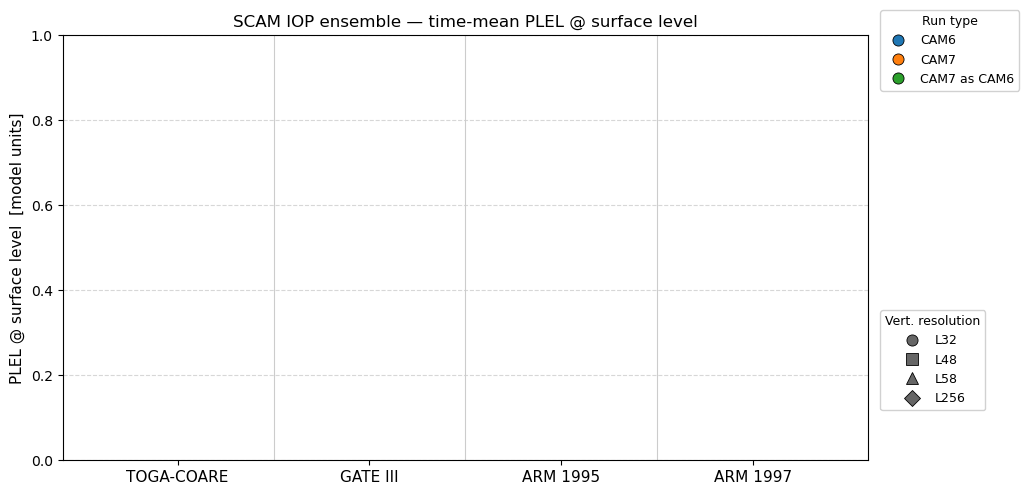

In [10]:
# ── run ───────────────────────────────────────────────────────────────────────
# stat     : "mean" | "min" | "max" | "std"  — which statistic to plot
# outfile  : None = auto-named, e.g. PRECT_mean.png, T_850hPa_std.png
#
# Level selection (3-D variables):
#   plev    = 850.  → nearest model level; prints selected lev index per resolution
#   lev_idx = 20    → exact 0-based level index (overrides plev)
#   both None       → vertical mean
#
# Examples:
#   make_plot("PRECT", stat="mean", obs=True)
#   make_plot("PRECT", stat="std")
#   make_plot("T", plev=850, stat="min")
#   make_plot("ZMDT", lev_idx=20, stat="max")

varname = "PLEL"
plev    = None     # pressure in hPa, else None
lev_idx = -1     # 0-based level index (overrides plev), else None
outfile = None     # None = auto-generate filename
obs     = None
stat    = "mean"   # "mean" | "min" | "max" | "std"

make_plot(varname, plev=plev, lev_idx=lev_idx, outfile=outfile, obs=obs, stat=stat)